# 01 — Heart Disease Prediction: VitalsAI

This notebook trains a **Stacking Ensemble Model** (Random Forest + XGBoost + Logistic Regression) on the CDC BRFSS 2015 dataset to predict heart disease risk.

**Key steps:**
- Exploratory Data Analysis (EDA)
- SMOTE for class imbalance
- Stacking Ensemble training
- Threshold optimization
- Model saving for VitalsAI deployment

## 1. Setup & Imports

In [1]:
# Install libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
!pip install scikit-learn==1.6.1 xgboost==3.2.0 -q

## 2. Load Data
Loading the CDC BRFSS 2015 Heart Disease dataset from Google Drive.

In [4]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')



Mounted at /content/drive


In [5]:
# Path where your file is stored in Drive
df = pd.read_csv("/content/drive/MyDrive/heart_disease_health_indicators_BRFSS2015.csv")

## 3. Exploratory Data Analysis (EDA)
### 3.1 Basic Info & Shape

In [6]:
# Shape and first rows
print(df.shape)
print(df.head())


(253680, 22)
   HeartDiseaseorAttack  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0                   0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1                   0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2                   0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3                   0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4                   0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   Diabetes  PhysActivity  Fruits  ...  AnyHealthcare  NoDocbcCost  GenHlth  \
0       0.0           0.0     0.0  ...            1.0          0.0      5.0   
1       0.0           1.0     0.0  ...            0.0          1.0      3.0   
2       0.0           0.0     1.0  ...            1.0          1.0      5.0   
3       0.0           1.0     1.0  ...            1.0          0.0      2.0   
4       0.0           1.0     1.0  ...            1.0          0.0      2.0   

   MentHlth  PhysHlth  DiffWalk  Sex   Age 

In [7]:
# Info and summary
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   HeartDiseaseorAttack  253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   Diabetes              253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

### 3.2 Missing Values

In [9]:
print(df.isnull().sum())


HeartDiseaseorAttack    0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
Diabetes                0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


### 3.3 Class Distribution — Heart Disease

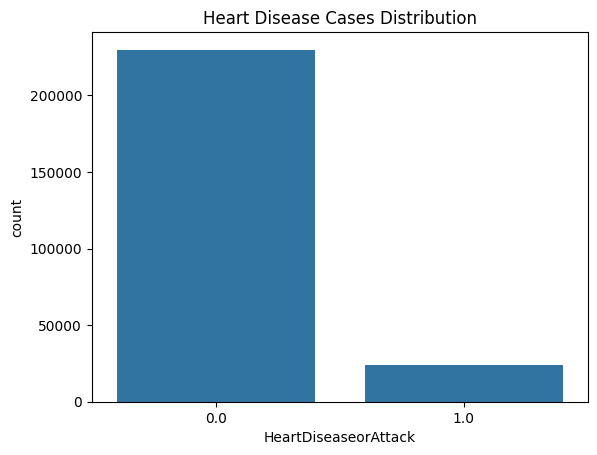

In [8]:
sns.countplot(x="HeartDiseaseorAttack", data=df)
plt.title("Heart Disease Cases Distribution")
plt.show()

### 3.4 Feature Distributions

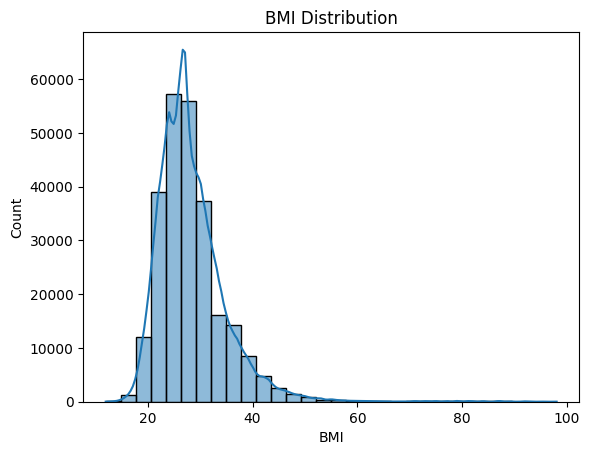

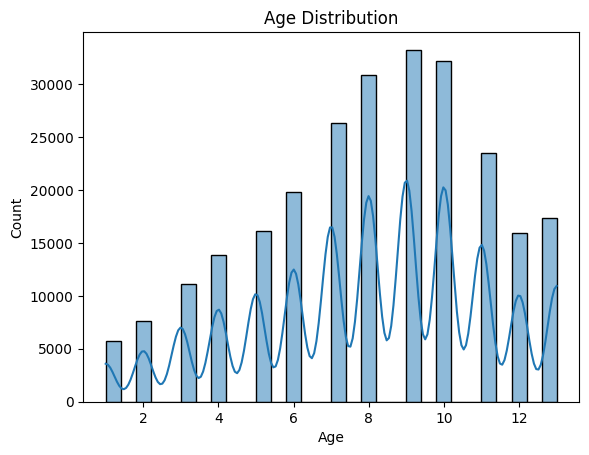

In [10]:
sns.histplot(df["BMI"], bins=30, kde=True)
plt.title("BMI Distribution")
plt.show()

sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()


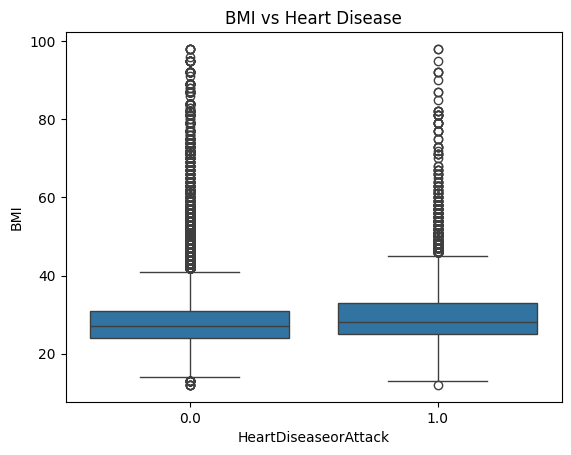

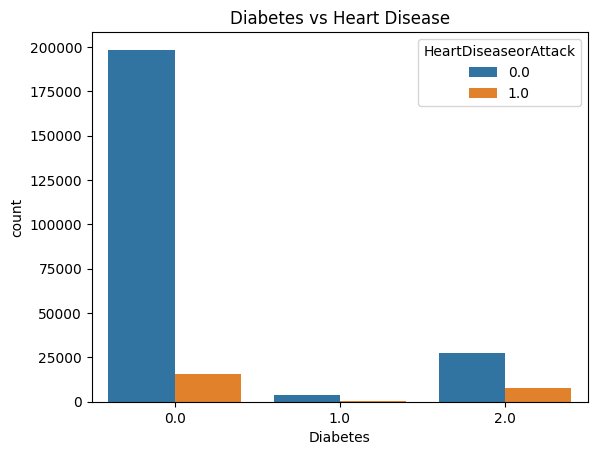

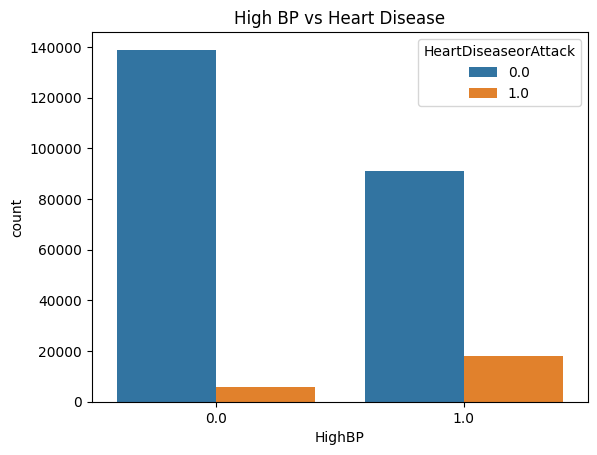

In [11]:
sns.boxplot(x="HeartDiseaseorAttack", y="BMI", data=df)
plt.title("BMI vs Heart Disease")
plt.show()

sns.countplot(x="Diabetes", hue="HeartDiseaseorAttack", data=df)
plt.title("Diabetes vs Heart Disease")
plt.show()

sns.countplot(x="HighBP", hue="HeartDiseaseorAttack", data=df)
plt.title("High BP vs Heart Disease")
plt.show()


### 3.5 Correlation Heatmap

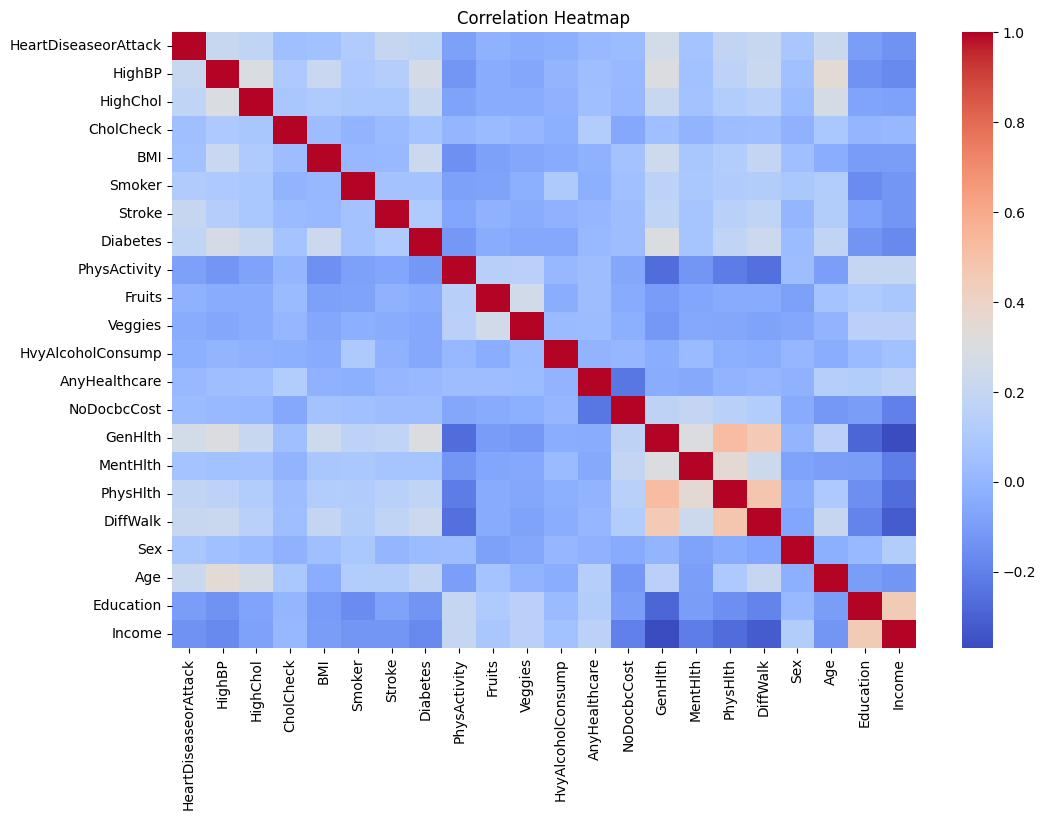

In [12]:
corr = df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()


## 4. Feature Selection & Preprocessing
Selecting 9 key clinical features and splitting data.

In [13]:
# Features (input variables)
selected_features = ["Age","BMI","HighBP","HighChol","Diabetes",
                     "Smoker","PhysActivity","GenHlth","Sex"]

X = df[selected_features]

# Target (output variable)
y = df["HeartDiseaseorAttack"]


In [14]:
from sklearn.model_selection import train_test_split

X = df[["Age","BMI","HighBP","HighChol","Diabetes",
        "Smoker","PhysActivity","GenHlth","Sex"]]
y = df["HeartDiseaseorAttack"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


## 5. Handling Class Imbalance — SMOTE
Applying Synthetic Minority Over-sampling Technique (SMOTE) to balance the dataset.

In [15]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Initialize SMOTE to balance the minority class
smote = SMOTE(random_state=42)

# Resample only the training data
# This creates synthetic samples for Class 1 so it matches the count of Class 0
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Check the new distribution
print(f"Original dataset distribution: {Counter(y_train)}")
print(f"Resampled dataset distribution: {Counter(y_train_res)}")


Original dataset distribution: Counter({0.0: 183830, 1.0: 19114})
Resampled dataset distribution: Counter({0.0: 183830, 1.0: 183830})


## 6. Base Model Training
### 6.1 Logistic Regression

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

log_reg = LogisticRegression(class_weight="balanced", max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)

print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))


              precision    recall  f1-score   support

         0.0       0.97      0.73      0.84     45957
         1.0       0.24      0.79      0.36      4779

    accuracy                           0.74     50736
   macro avg       0.60      0.76      0.60     50736
weighted avg       0.90      0.74      0.79     50736

[[33745 12212]
 [  990  3789]]


### 6.2 Random Forest

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

         0.0       0.94      0.85      0.89     45957
         1.0       0.24      0.46      0.31      4779

    accuracy                           0.81     50736
   macro avg       0.59      0.65      0.60     50736
weighted avg       0.87      0.81      0.84     50736



### 6.3 ROC-AUC Comparison

In [18]:
from sklearn.metrics import roc_auc_score

print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, log_reg.predict_proba(X_test)[:,1]))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))


Logistic Regression ROC-AUC: 0.8376978875096189
Random Forest ROC-AUC: 0.7377530820760545


## 7. Stacking Ensemble Model
Combining RF + XGBoost + SVC with Logistic Regression as meta-learner.

In [19]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Base learners (weak + strong models)
estimators = [
    ('rf', RandomForestClassifier(class_weight="balanced", random_state=42)),
    ('gb', GradientBoostingClassifier(random_state=42))
]

# Meta-model (final estimator)
stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(class_weight="balanced", max_iter=1000),
    passthrough=True   # base learners’ predictions + original features both meta-model ma jaye
)

# Train stacking model
stack_model.fit(X_train, y_train)

# Predictions
y_pred_stack = stack_model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred_stack))
print("Stacking ROC-AUC:", roc_auc_score(y_test, stack_model.predict_proba(X_test)[:,1]))


              precision    recall  f1-score   support

         0.0       0.97      0.73      0.84     45957
         1.0       0.24      0.79      0.36      4779

    accuracy                           0.74     50736
   macro avg       0.60      0.76      0.60     50736
weighted avg       0.90      0.74      0.79     50736

Stacking ROC-AUC: 0.8377144700567394


In [22]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Save feature names BEFORE training
feature_names = list(X_train.columns)
print('Feature order:', feature_names)

base_learners = [
    ('rf', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        max_depth=8,
        min_samples_leaf=2,
        random_state=42
    )),
    ('xgb', XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=9,
        random_state=42,
        eval_metric='logloss'
    )),
    ('gb', GradientBoostingClassifier(
        n_estimators=150,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        random_state=42
    ))
]

stack_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        C=0.5
    ),
    passthrough=False,   # ← FALSE: feature order mismatch fix
    cv=5,
    stack_method='predict_proba'
)

stack_model.fit(X_train_res, y_train_res)
print('Heart stacking model trained ✅')


Feature order: ['Age', 'BMI', 'HighBP', 'HighChol', 'Diabetes', 'Smoker', 'PhysActivity', 'GenHlth', 'Sex']
Heart stacking model trained ✅


### 7.1 Cross-Validation

In [20]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(stack_model, X, y, cv=5, scoring='roc_auc')
print("Cross-validated ROC-AUC:", scores.mean())

Cross-validated ROC-AUC: 0.837880028011651


### 7.2 Feature Importance

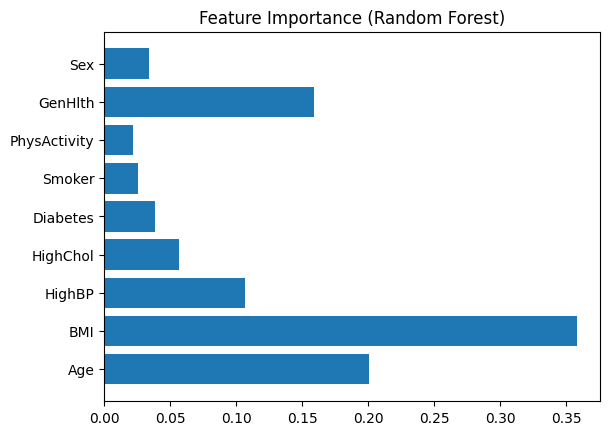

In [21]:
import matplotlib.pyplot as plt

importances = stack_model.named_estimators_['rf'].feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance (Random Forest)")
plt.show()


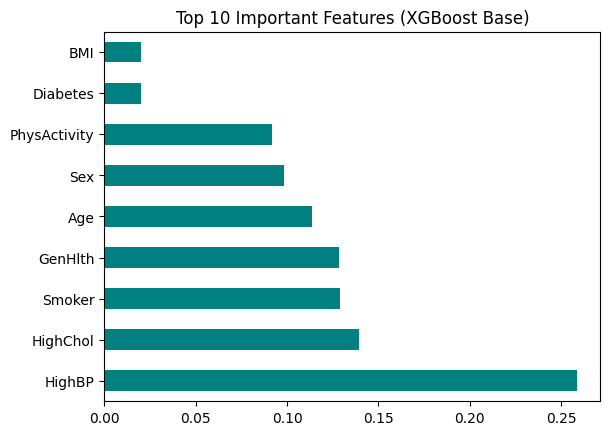

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from the XGBoost part of the stack
# Since XGBoost is a strong base learner, its importance is very useful
xgb_model = stack_model.named_estimators_['xgb']
importance = xgb_model.feature_importances_

# Create a plot
feat_importances = pd.Series(importance, index=X_train.columns)
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title("Top 10 Important Features (XGBoost Base)")
plt.show()


## 8. Model Evaluation
### 8.1 Classification Report & Confusion Matrix

In [23]:
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score, balanced_accuracy_score

y_probs = stack_model.predict_proba(X_test)[:, 1]

# Optimal threshold = 0.30 for better heart disease recall
custom_threshold = 0.30
y_pred_custom = (y_probs >= custom_threshold).astype(int)

print(f'--- Results with Threshold: {custom_threshold} ---')
print(classification_report(y_test, y_pred_custom, target_names=['No Disease', 'Heart Disease']))
print('ROC-AUC:', round(roc_auc_score(y_test, y_probs), 4))
print('Balanced Accuracy:', round(balanced_accuracy_score(y_test, y_pred_custom), 4))

# Disease detection rate
disease_mask = y_test == 1
detection_rate = (y_pred_custom[disease_mask] == 1).mean()
print(f'Heart Disease Detection Rate: {detection_rate:.2%}')


--- Results with Threshold: 0.3 ---
               precision    recall  f1-score   support

   No Disease       0.97      0.77      0.86     45957
Heart Disease       0.25      0.73      0.37      4779

     accuracy                           0.77     50736
    macro avg       0.61      0.75      0.62     50736
 weighted avg       0.90      0.77      0.81     50736

ROC-AUC: 0.8297
Balanced Accuracy: 0.753
Heart Disease Detection Rate: 73.22%


### 8.2 Threshold Optimization
Finding the best threshold for high sensitivity in disease detection.

In [25]:
# Testing different thresholds to find the best balance
thresholds = [0.3, 0.4, 0.45, 0.5, 0.55, 0.6]

for t in thresholds:
    y_pred_t = (y_probs >= t).astype(int)
    from sklearn.metrics import precision_score, recall_score, f1_score

    p = precision_score(y_test, y_pred_t)
    r = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)

    print(f"Threshold: {t:.2f} | Precision: {p:.2f} | Recall: {r:.2f} | F1-Score: {f1:.2f}")


Threshold: 0.30 | Precision: 0.25 | Recall: 0.73 | F1-Score: 0.37
Threshold: 0.40 | Precision: 0.27 | Recall: 0.67 | F1-Score: 0.39
Threshold: 0.45 | Precision: 0.28 | Recall: 0.65 | F1-Score: 0.40
Threshold: 0.50 | Precision: 0.29 | Recall: 0.62 | F1-Score: 0.40
Threshold: 0.55 | Precision: 0.31 | Recall: 0.58 | F1-Score: 0.40
Threshold: 0.60 | Precision: 0.32 | Recall: 0.54 | F1-Score: 0.40


## 9. Save Model for VitalsAI Deployment
Saving trained model as `.pkl` file for Flask API integration.

In [27]:
import joblib, os

os.makedirs('models', exist_ok=True)
joblib.dump(stack_model,   'models/final_stacking_model.pkl')
joblib.dump(feature_names, 'models/heart_features.pkl')  # feature order save
print('Saved locally ✅')
print('Feature order saved:', feature_names)

try:
    os.makedirs('/content/drive/MyDrive/VitalsAI_models', exist_ok=True)
    joblib.dump(stack_model,   '/content/drive/MyDrive/VitalsAI_models/final_stacking_model.pkl')
    joblib.dump(feature_names, '/content/drive/MyDrive/VitalsAI_models/heart_features.pkl')
    print('Saved to Google Drive ✅')
except:
    print('Drive save skipped')


Saved locally ✅
Feature order saved: ['Age', 'BMI', 'HighBP', 'HighChol', 'Diabetes', 'Smoker', 'PhysActivity', 'GenHlth', 'Sex']
Saved to Google Drive ✅


In [29]:
import joblib

# 1. Save the final stacking model
# This 'pkl' file is your brain for the project
joblib.dump(stack_model, 'diabetes_stacking_model.pkl')
print("Model saved successfully!")

# 2. Prediction on completely new data
# Imagine we have a new patient with features like HighBP=1, HighChol=1, BMI=28, etc.
def final_prediction(new_data_features, model, threshold=0.30):
    """
    Takes features of a new patient and returns 1 (Diabetes) or 0 (No Diabetes)
    """
    prob = model.predict_proba(new_data_features)[:, 1]
    prediction = (prob >= threshold).astype(int)
    return prediction, prob

# Example usage with your saved model
# result, probability = final_prediction(X_test.iloc[:5], stack_model)


Model saved successfully!


## 10. Sample Prediction Test

In [30]:
# 1. Prediction Function for Heart Disease
# Using our optimized threshold of 0.30 for better recall
def heart_risk_analyzer(model, patient_data, threshold=0.30):
    """
    Analyzes patient data to predict Heart Disease Risk using the Stacking Model.
    """
    # Get the probability scores from the stacking model
    prob = model.predict_proba(patient_data)[:, 1]

    # Determine the status based on our custom threshold
    prediction = (prob >= threshold).astype(int)

    return prediction[0], prob[0]

# 2. Manual Patient Testing (Let's use a real sample from X_test for accuracy)
# You can also manually type values in a list like: [1, 0, 24, 0, 1, ...]
# But it must match the order and number of columns in X_train.
sample_patient_idx = 10 # Change this index to test different patients
patient_to_test = X_test.iloc[sample_patient_idx : sample_patient_idx + 1]

# 3. Execute the analysis
status, risk_percent = heart_risk_analyzer(stack_model, patient_to_test)

# 4. Display the Result
print(f"--- HEART DISEASE RISK ANALYSIS REPORT ---")
print(f"Risk Probability: {risk_percent:.2%}")
print(f"Final Conclusion: {'HIGH RISK of Heart Disease' if status == 1 else 'LOW RISK'}")
print(f"Actual Label in Data: {'Heart Disease' if y_test.iloc[sample_patient_idx] == 1 else 'Healthy'}")


--- HEART DISEASE RISK ANALYSIS REPORT ---
Risk Probability: 4.13%
Final Conclusion: LOW RISK
Actual Label in Data: Healthy
